In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from transformers import GPT2Tokenizer, GPT2LMHeadModel, AutoTokenizer, AutoModelForCausalLM
import numpy as np
import torch
from collections import defaultdict

In [18]:
with open('./trim.txt', 'r', encoding='utf-8') as file:
    trim_data = [line.strip() for line in file]

In [4]:
model = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [5]:
def calculate_perplexity(text):
    inputs = tokenizer.encode(text, return_tensors="pt")
    with torch.no_grad():
        outputs = model(inputs, labels=inputs)
        loss = outputs.loss
        perplexity = torch.exp(loss)
    return perplexity.item()

In [ ]:
class IcicleDiagramVisualizer:
    def __init__(self):
        self.tree = {}  # Main tree structure
        self.depths = defaultdict(list)  # Track words per depth

    def insert(self, sentence, perplexity):
        """ Insert a sentence into the tree structure with perplexity values. """
        perplexity = min(perplexity, 300)  # Clip perplexity at 300
        words = sentence.split()
        node = self.tree  # Start at root
        depth = 0

        for word in words:
            if word not in node:
                node[word] = {"children": {}, "perplexity": perplexity}
                self.depths[depth].append((word, node[word]))  # Store reference
            
            node = node[word]["children"]  # Move deeper into tree
            depth += 1

    def visualize(self):
        """ Draw a vertical icicle diagram where each column represents a depth level. """
        fig, ax = plt.subplots(figsize=(12, 6))
        max_depth = max(self.depths.keys()) + 1  # Total number of columns

        column_width = 1.0 / max_depth  # Set uniform column width
        
        # Collect all perplexity values for normalization
        all_perplexities = [node["perplexity"] for depth in self.depths.values() for _, node in depth]
        min_perp, max_perp = min(all_perplexities), max(all_perplexities)

        cmap = plt.cm.inferno  # Set colormap
        norm = plt.Normalize(vmin=min_perp, vmax=max_perp)  # Normalize perplexity values
        
        for depth, words in self.depths.items():
            num_words = len(words)
            row_height = 1.0 / num_words if num_words else 1.0  # Divide column evenly
            
            for i, (word, node) in enumerate(words):
                perplexity = node["perplexity"]  # Retrieve stored perplexity
                
                # Normalize perplexity between 0 and 1
                norm_perp = (perplexity - min_perp) / (max_perp - min_perp) if max_perp > min_perp else 0.5
                
                # Apply colormap
                color = cmap(norm(perplexity))

                rect = plt.Rectangle((depth * column_width, 1 - (i + 1) * row_height), 
                                    column_width, row_height, 
                                    facecolor=color)
                ax.add_patch(rect)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis("off")  # Remove axes for clean look
        plt.title("Perplexity in Branches")

        # Add x-axis labels for branch steps
        ax.set_xticks([(i + 0.5) / max_depth for i in range(max_depth)])  
        ax.set_xticklabels(range(1, max_depth + 1))
        ax.set_xlabel("Branch Steps")
        ax.axis("on")  # Turn axis back on to show labels
        ax.set_yticks([])

        # Add colorbar with reduced padding
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.01)  # Decreased pad value

        plt.show()


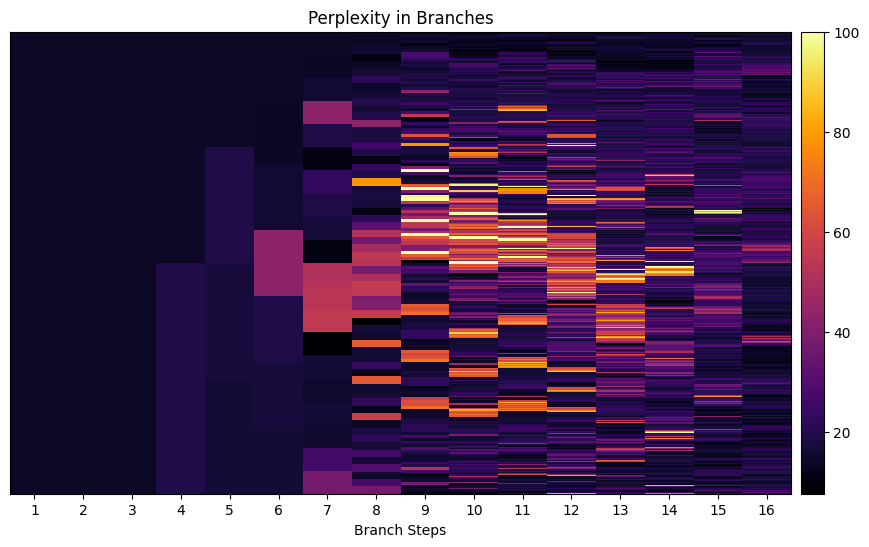

In [19]:
# Create icicle visualizer
visualizer = IcicleDiagramVisualizer()

# Delete the first 4 words of each sentence in sentences_test
text_data_test = [' '.join(sentence.split()[:]) for sentence in trim_data]

# Calculate perplexity for all sentences and store them
perplexity_values = []
for sentence in text_data_test:
    try:
        perplexity = calculate_perplexity(sentence)
        # Clip perplexity to a maximum of 100
        perplexity = min(perplexity, 100)
        perplexity_values.append(perplexity)
    except Exception as e:
        perplexity_values.append(0)  # Assign 0 if there's an error

# Insert sentences and their clipped perplexity into the visualizer
for sentence, perplexity in zip(text_data_test, perplexity_values):
    visualizer.insert(sentence, perplexity)

# Visualize the hierarchical icicle diagram
visualizer.visualize()